In [1]:
# This test file tests the fallback of the region extraction based on the default locations of the aruco markers when the ARUCO marker detection fails. It simulates a scenario where the ARUCO markers are not detected and verifies that the region extraction still works based on the default positions of the markers. The test checks that the extracted regions are correct and that the relative coordinates are consistent with the expected values based on the default marker positions.

import cv2
import matplotlib.pyplot as plt
import os
import sys
import numpy as np
from pathlib import Path

# Resolve project root robustly (works whether cwd is repo root or tests folder)
candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next(
	(root for root in candidate_roots if (root / "pipeline").exists() and (root / "configs").exists()),
	None
)
if project_root is None:
	raise RuntimeError("Could not find project root containing 'pipeline' and 'configs' folders.")

# Add root and module folders to sys.path for both direct and package-style imports
for p in [project_root, project_root / "pipeline", project_root / "configs"]:
	if str(p) not in sys.path:
		sys.path.append(str(p))

import aruco_handler
import preprocess_paper
from configs import config

config.set_active_system_config("system_config")
config.set_active_config("db9-2024")

# Load the image
image = plt.imread("aruco_marker_obstructed_test_image.png")
image = np.array(image*255, dtype=np.uint8)


# Add artifical tilt to the image to limit test the system"s ability to detect and correct for it
artificial_tilt_angle = 3  # degrees

# First pad the image to prevent cropping during rotation
(h, w) = image.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, artificial_tilt_angle, 1.0)
image = cv2.warpAffine(image, M, (w, h))

def plot_image(img, title="Image"):
	plt.figure(figsize=(6, 6))
	plt.imshow(img)
	plt.title(title)
	plt.show()

# Attempt to find aruco markers in the image
aruco_markers = aruco_handler.detect_aruco_markers(image)
print("Detected ARUCO markers:", aruco_markers)

Detected ARUCO markers: None


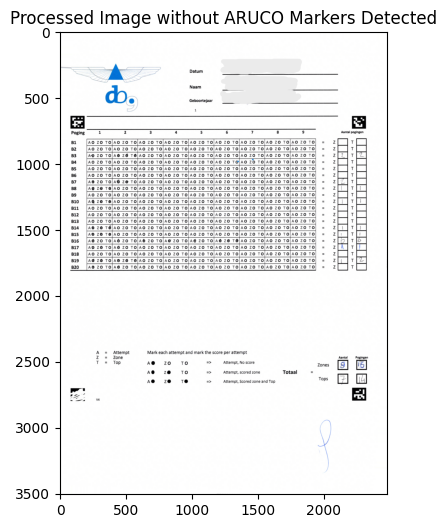

In [2]:
processed_image, aruco_markers = preprocess_paper.preprocess(image)

plot_image(processed_image, title="Processed Image without ARUCO Markers Detected")